In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('/content/all_exoplanets_2021.csv.crdownload')

In [3]:
df.size

105225

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4575 entries, 0 to 4574
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   No.                            4575 non-null   int64  
 1   Planet Name                    4575 non-null   object 
 2   Planet Host                    4575 non-null   object 
 3   Num Stars                      4575 non-null   int64  
 4   Num Planets                    4575 non-null   int64  
 5   Discovery Method               4575 non-null   object 
 6   Discovery Year                 4575 non-null   int64  
 7   Discovery Facility             4575 non-null   object 
 8   Orbital Period Days            4413 non-null   float64
 9   Orbit Semi-Major Axis          2763 non-null   float64
 10  Mass                           2006 non-null   float64
 11  Eccentricity                   1707 non-null   float64
 12  Insolation Flux                370 non-null    f

In [5]:
df.isnull().sum()

,0
No.,0
Planet Name,0
Planet Host,0
Num Stars,0
Num Planets,0
Discovery Method,0
Discovery Year,0
Discovery Facility,0
Orbital Period Days,162
Orbit Semi-Major Axis,1812


In [6]:
df = df.drop(['No.', 'Planet Name', 'Planet Host',
              'Discovery Method', 'Discovery Facility',
              'Spectral Type', 'Stellar Metallicity Ratio'], axis=1, errors='ignore')

Missing values heatmap:

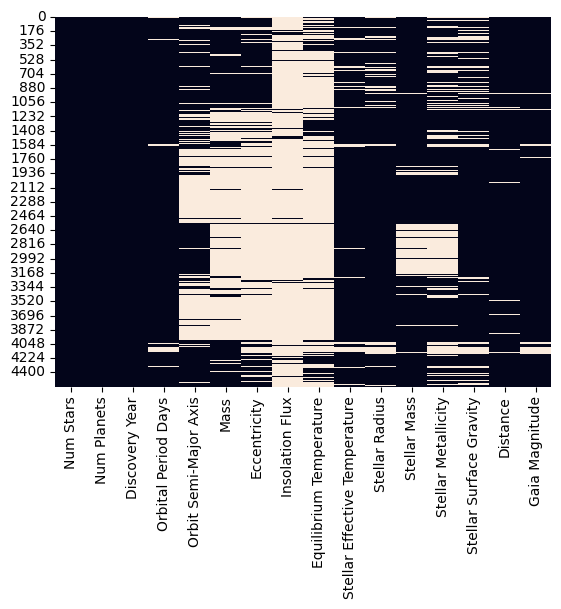

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()


In [8]:
# Missing value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

Insolation Flux                  91.912568
Equilibrium Temperature          79.781421
Eccentricity                     62.688525
Mass                             56.153005
Orbit Semi-Major Axis            39.606557
Stellar Metallicity              29.967213
Stellar Mass                     15.978142
Stellar Surface Gravity          13.180328
Stellar Radius                    9.770492
Stellar Effective Temperature     7.628415
Gaia Magnitude                    3.825137
Orbital Period Days               3.540984
Distance                          2.273224
Num Planets                       0.000000
Discovery Year                    0.000000
Num Stars                         0.000000
dtype: float64


Handling missing values(i used median)

In [9]:
df.fillna(df.median(), inplace=True)

In [10]:
def habitability_label(row):
    score = 0

    # Distance
    if 0.95 <= row['Orbit Semi-Major Axis'] <= 1.37:
        score += 1

    # Temperature
    if 250 <= row['Equilibrium Temperature'] <= 330:
        score += 1

    # Mass
    if 0.1 <= row['Mass'] <= 5:
        score += 1

    return 1 if score >= 2 else 0


df['Habitability'] = df.apply(habitability_label, axis=1)


In [11]:
df.head(5)

,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Habitability
0,2,1,2007,326.03000,1.29,6165.6000,0.231,45.7,961.0,4742.0,19.00,2.70,-0.35,2.31,93.1846,4.44038,0
1,1,1,2009,516.21997,1.53,4684.8142,0.080,45.7,961.0,4213.0,29.79,2.78,-0.02,1.93,125.3210,4.56216,0
2,1,1,2008,185.84000,0.83,1525.5000,0.000,45.7,961.0,4813.0,11.00,2.20,-0.24,2.63,75.4392,4.91781,0
3,1,2,2002,1773.40002,2.93,1481.0878,0.370,45.7,961.0,5338.0,0.93,0.90,0.41,4.45,17.9323,6.38300,0
4,3,1,1996,798.50000,1.66,565.7374,0.680,45.7,961.0,5750.0,1.13,1.08,0.06,4.36,21.1397,6.06428,0


In [12]:
df.sample(5)

,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Habitability
1349,2,4,2018,0.658524,0.01306,11.26782,0.092,879.5,1515.0,4285.0,0.70,0.69,-0.12,4.58,77.5586,11.35270,0
3501,1,1,2016,6.412515,0.11510,220.88734,0.092,45.7,961.0,5820.0,1.01,1.00,-0.02,4.43,946.6830,14.65700,0
4439,1,1,2010,4.317680,0.11510,177.98480,0.040,45.7,961.0,5700.0,0.91,0.96,-0.02,4.50,132.0960,10.20460,0
986,1,1,2007,422.900000,1.19100,861.31930,0.110,45.7,961.0,5963.0,1.58,1.26,0.28,4.45,78.0505,7.89597,0
2401,1,1,2016,56.644928,0.11510,220.88734,0.092,45.7,961.0,6228.0,2.15,1.47,0.12,3.94,1002.0200,12.57550,0


In [13]:
df['Habitability'].value_counts()

,count
Habitability,
0,4567
1,8


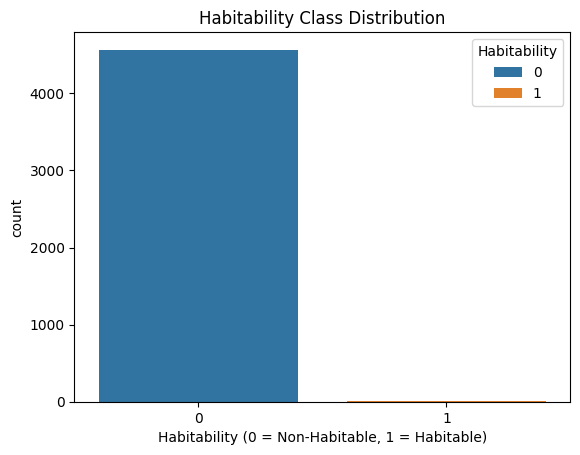

In [14]:
sns.countplot(x='Habitability', data=df, hue='Habitability')
plt.title("Habitability Class Distribution")
plt.xlabel("Habitability (0 = Non-Habitable, 1 = Habitable)")
plt.show()

In [15]:
X = df.drop('Habitability', axis=1)
y = df['Habitability']


outliers

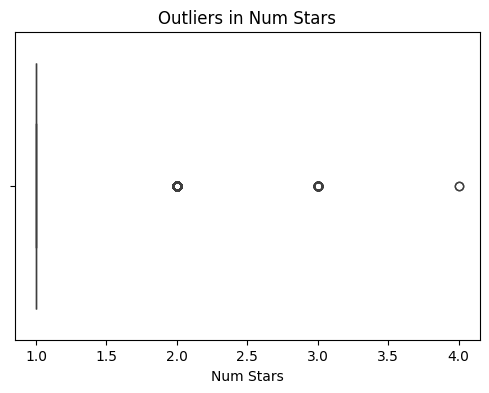

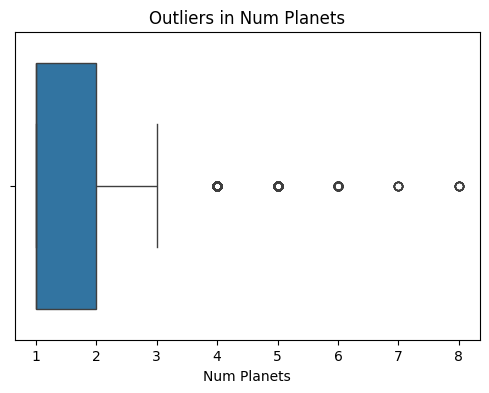

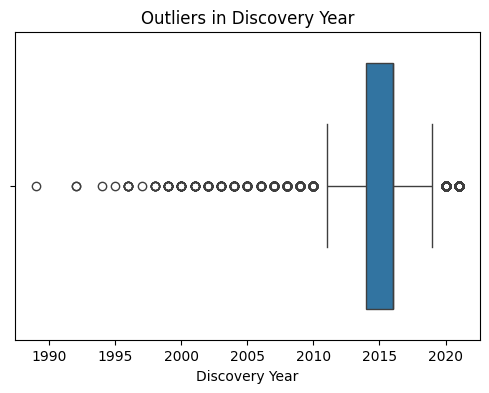

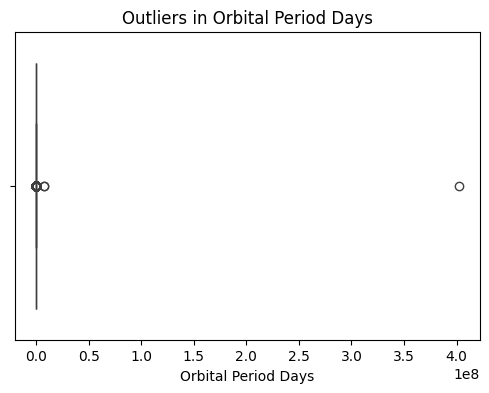

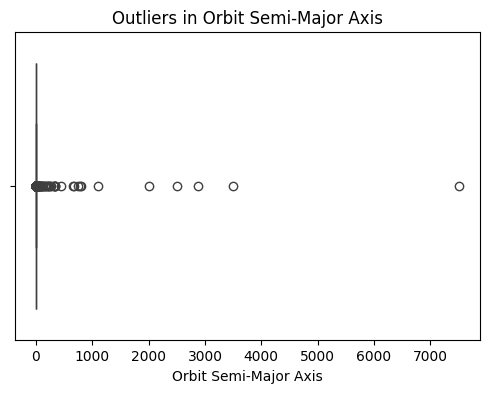

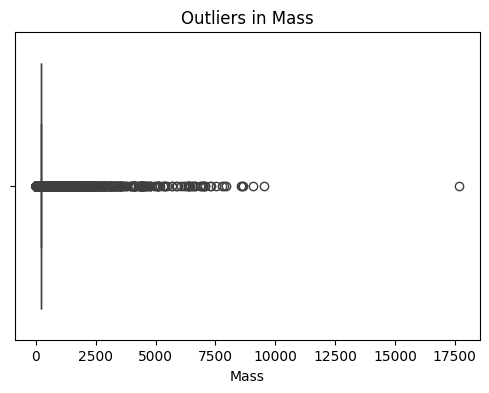

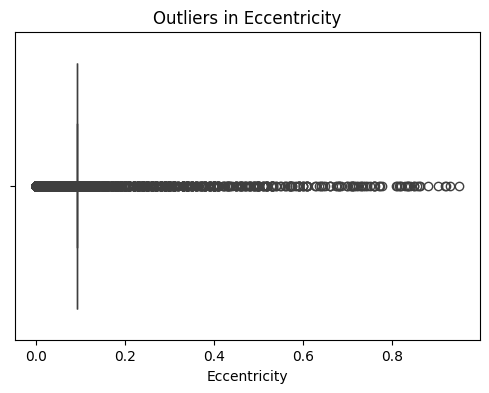

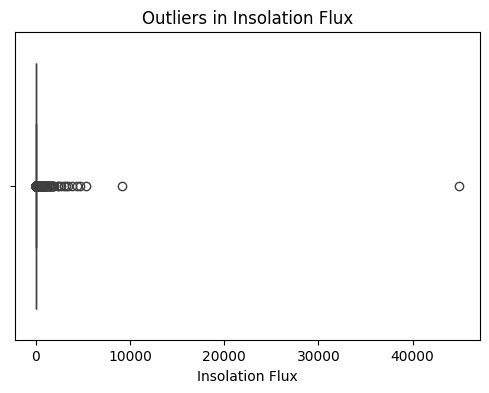

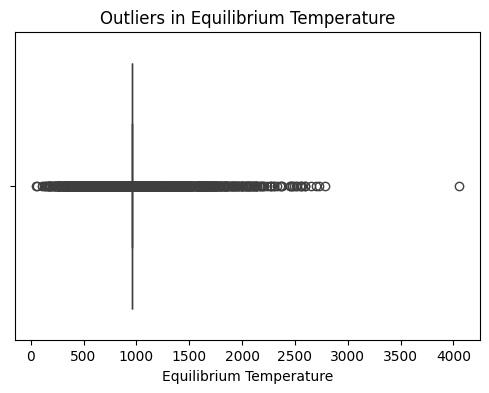

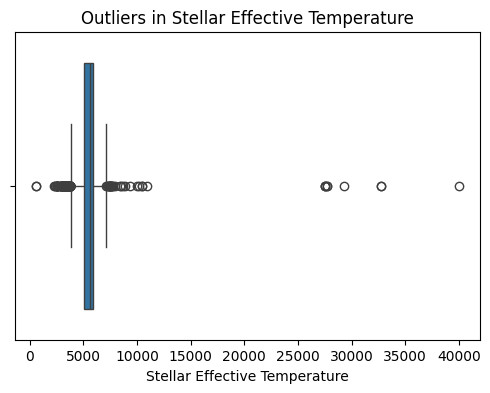

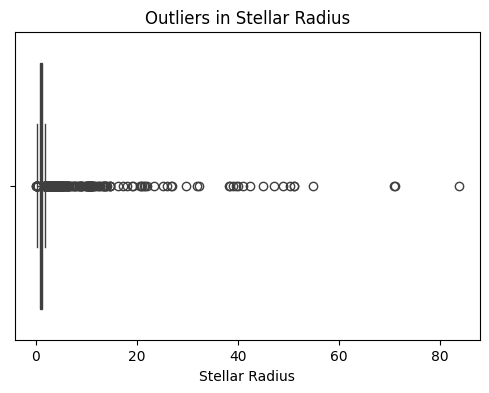

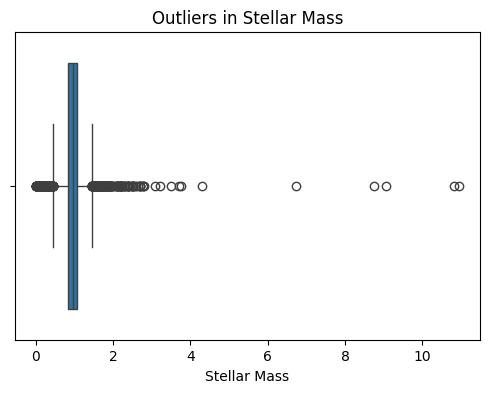

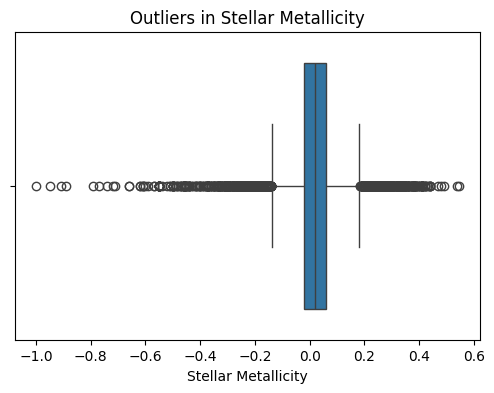

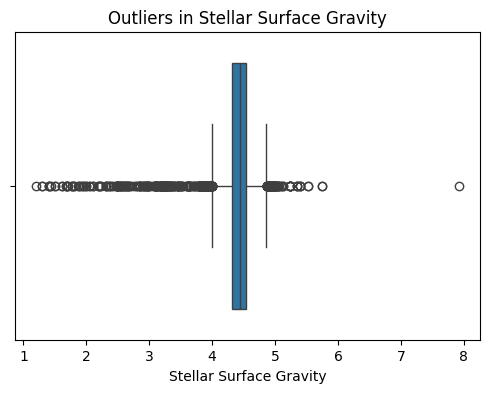

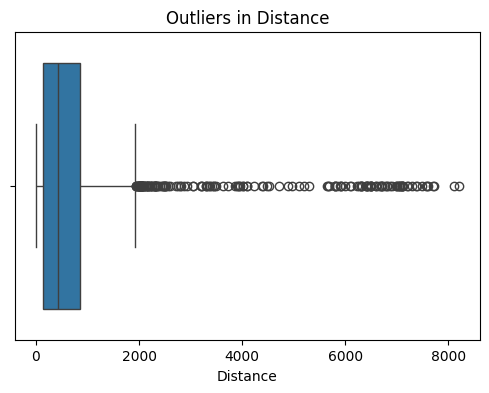

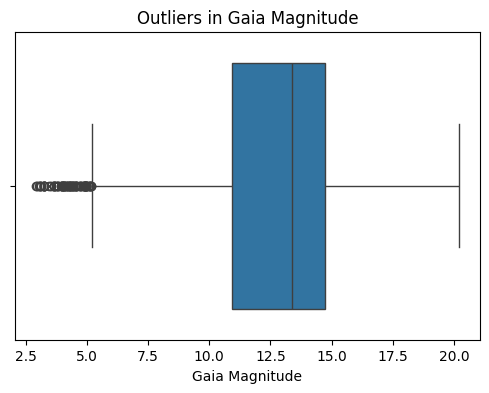

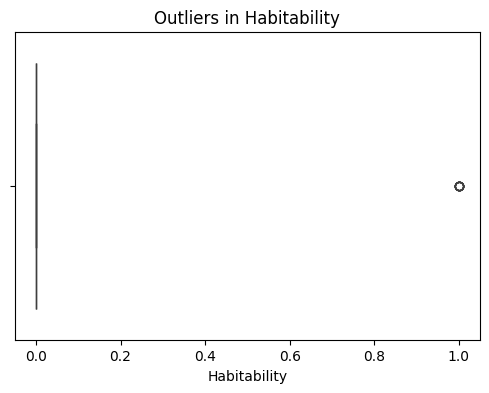

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


In [20]:
df_no_outliers = df.copy()

for col in num_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)


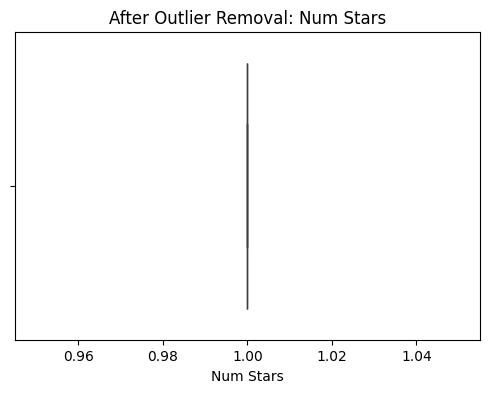

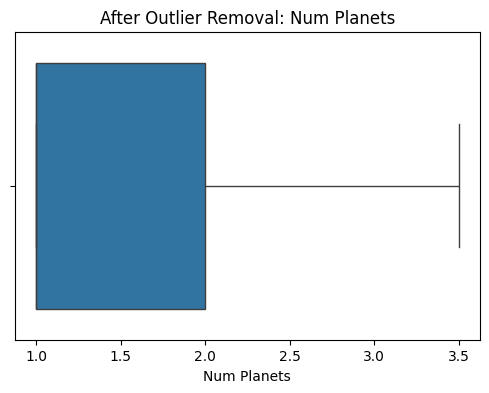

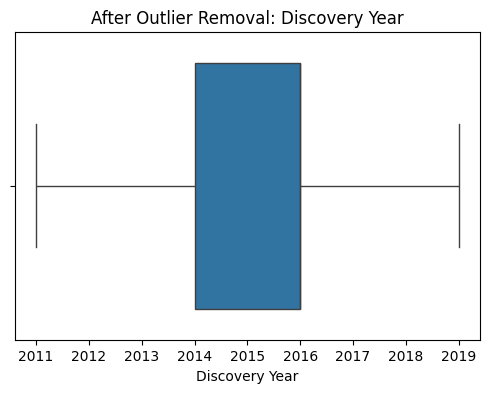

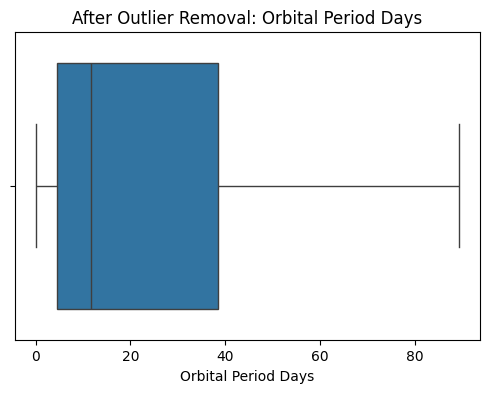

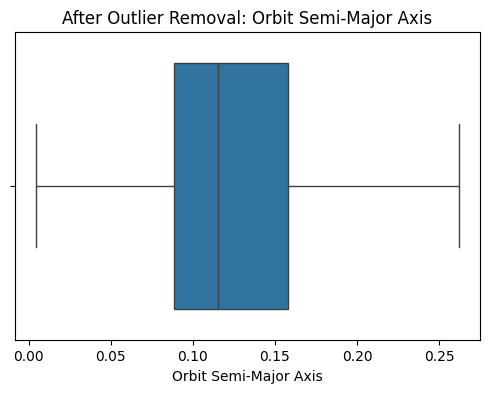

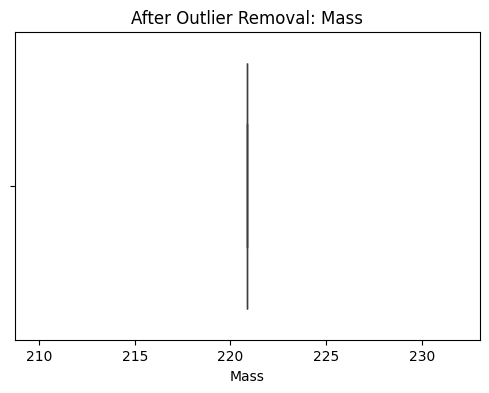

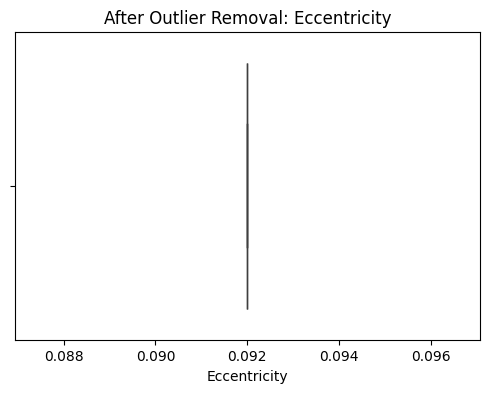

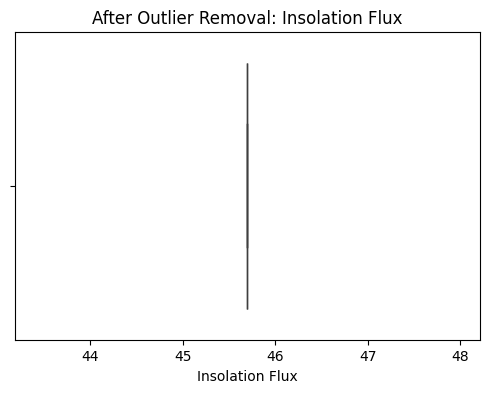

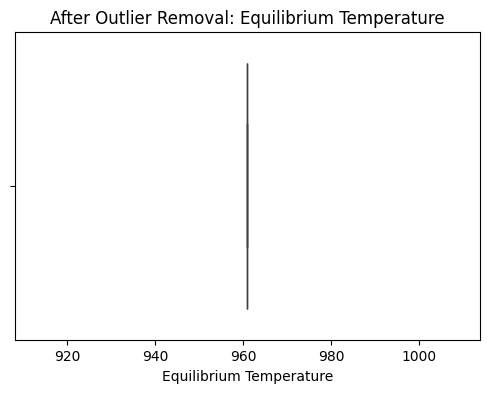

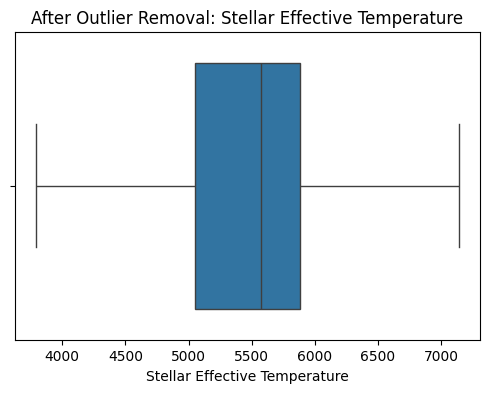

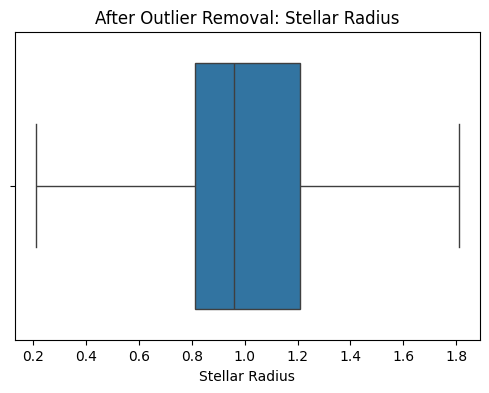

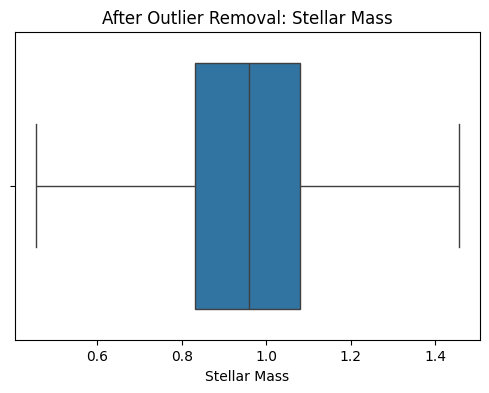

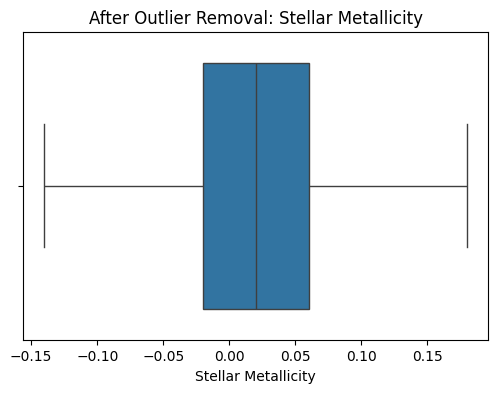

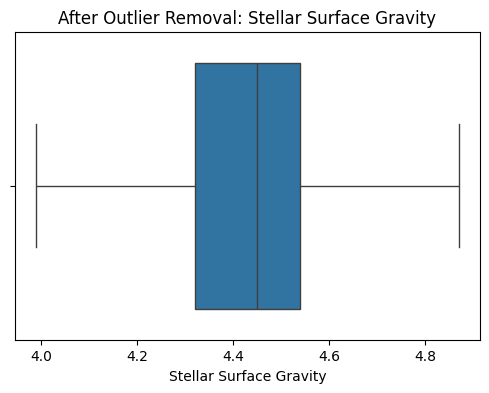

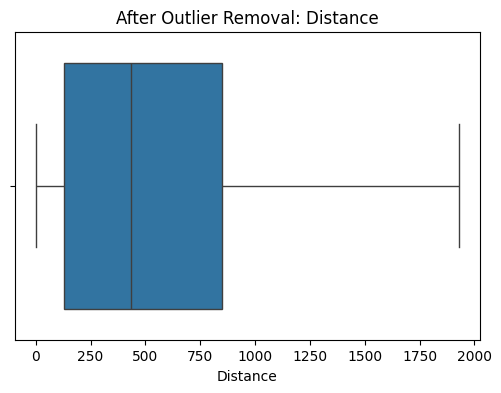

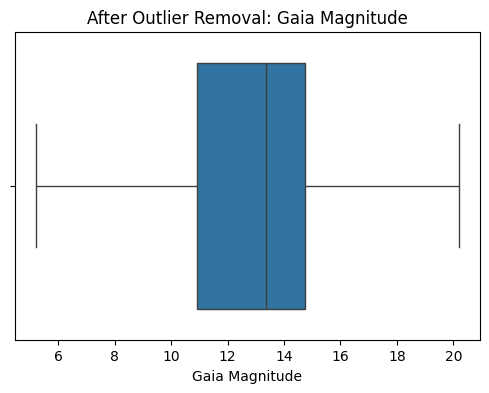

In [21]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_no_outliers[col])
    plt.title(f"After Outlier Removal: {col}")
    plt.show()


**Exploratory Data Analysis (EDA)**

In [22]:
#Descriptive statistics:
df.describe()


,Num Stars,Num Planets,Discovery Year,Orbital Period Days,Orbit Semi-Major Axis,Mass,Eccentricity,Insolation Flux,Equilibrium Temperature,Stellar Effective Temperature,Stellar Radius,Stellar Mass,Stellar Metallicity,Stellar Surface Gravity,Distance,Gaia Magnitude,Habitability
count,4575.000000,4575.000000,4575.000000,4.575000e+03,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000,4575.000000
mean,1.109945,1.787760,2014.862951,9.153937e+04,6.652859,441.979821,0.115473,78.127226,980.573989,5449.452337,1.479091,0.970728,0.015048,4.375204,651.338242,12.467618,0.001749
std,0.351677,1.166591,3.960923,5.945453e+06,141.836752,920.534070,0.116000,706.172087,255.209655,1365.478692,3.631064,0.434346,0.150282,0.402582,928.266306,2.940197,0.041785
min,1.000000,1.000000,1989.000000,9.070629e-02,0.004400,0.020000,0.000000,0.060000,50.000000,575.000000,0.010000,0.010000,-1.000000,1.200000,1.301190,2.926270,0.000000
25%,1.000000,1.000000,2014.000000,4.599537e+00,0.088650,220.887340,0.092000,45.700000,961.000000,5047.500000,0.810000,0.830000,-0.020000,4.320000,128.106000,10.934200,0.000000
50%,1.000000,1.000000,2016.000000,1.176305e+01,0.115100,220.887340,0.092000,45.700000,961.000000,5574.000000,0.960000,0.960000,0.020000,4.450000,434.754000,13.358800,0.000000
75%,1.000000,2.000000,2016.000000,3.849205e+01,0.158000,220.887340,0.092000,45.700000,961.000000,5884.000000,1.210000,1.080000,0.060000,4.540000,848.138500,14.744200,0.000000
max,4.000000,8.000000,2021.000000,4.020000e+08,7506.000000,17668.169700,0.950000,44900.000000,4050.000000,40000.000000,83.800000,10.940000,0.545000,7.920000,8200.000000,20.186100,1.000000


Validate Data Quality

Distribution plots (univariate):

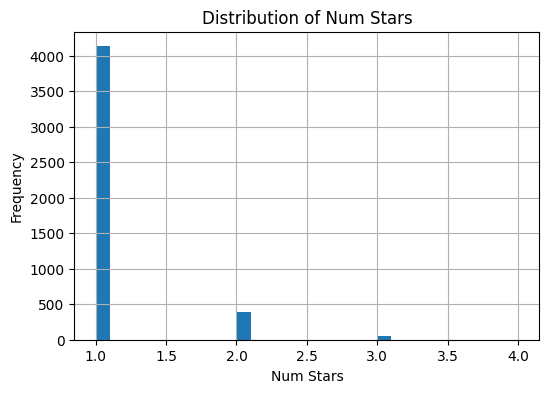

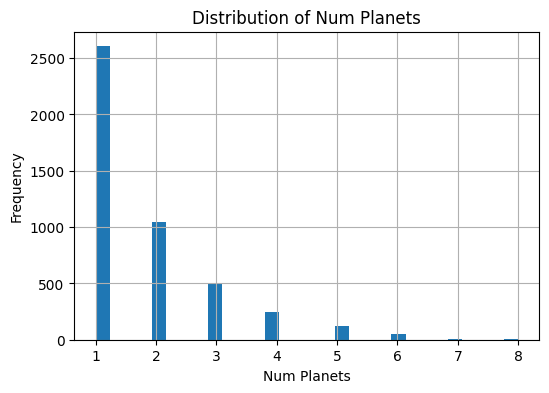

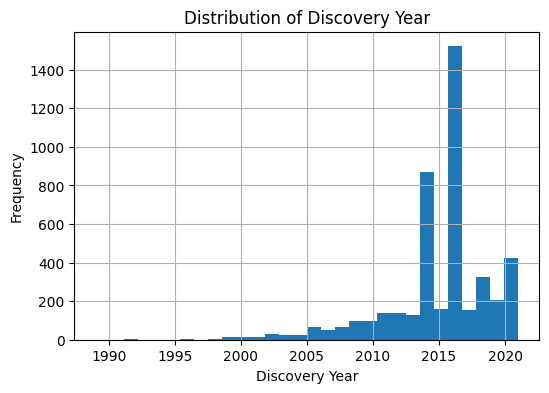

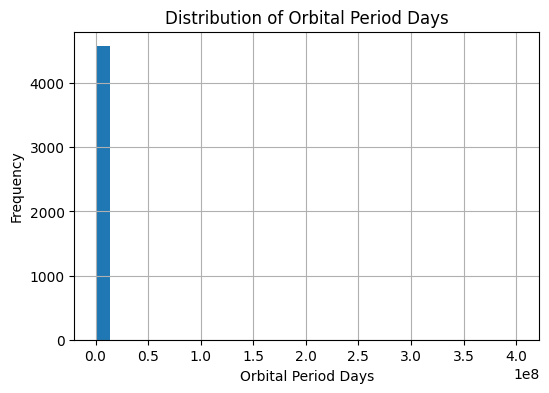

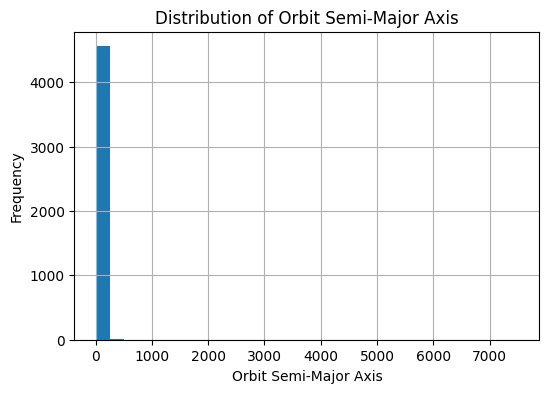

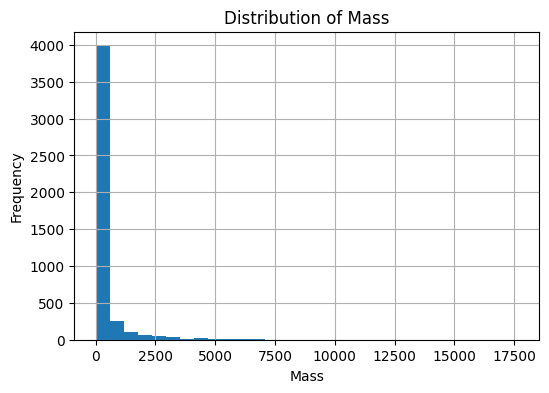

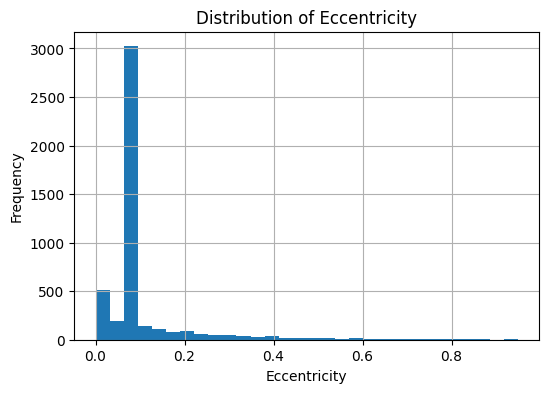

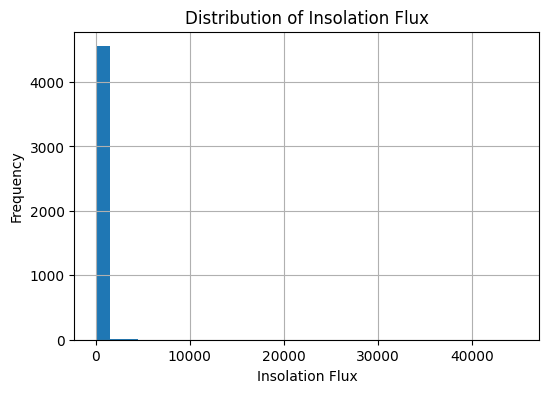

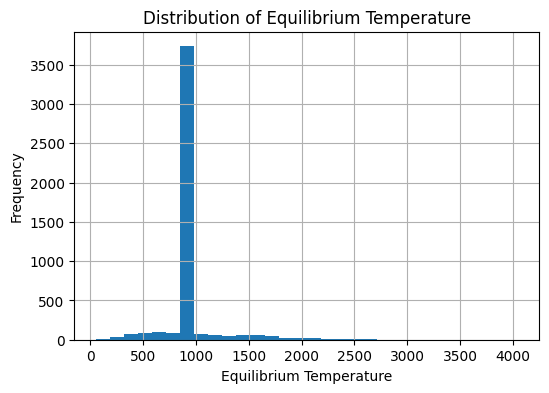

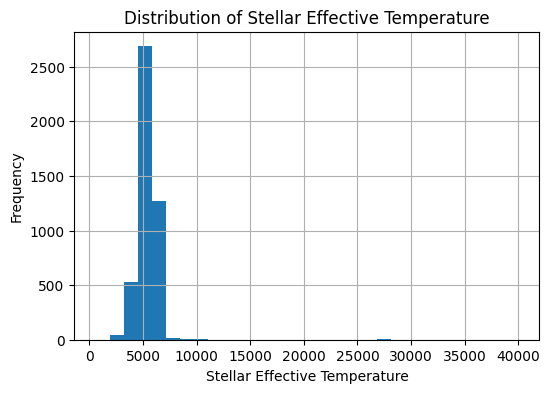

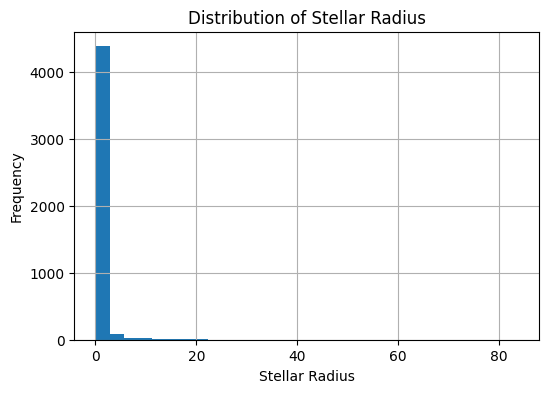

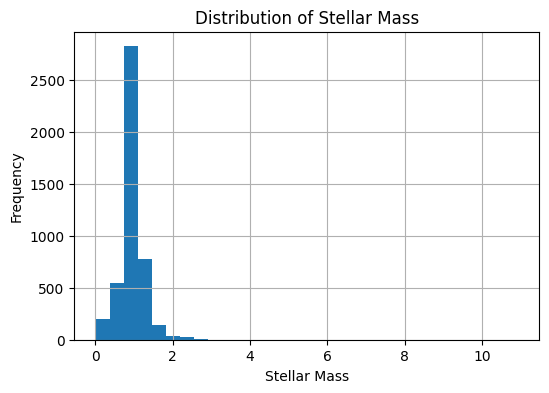

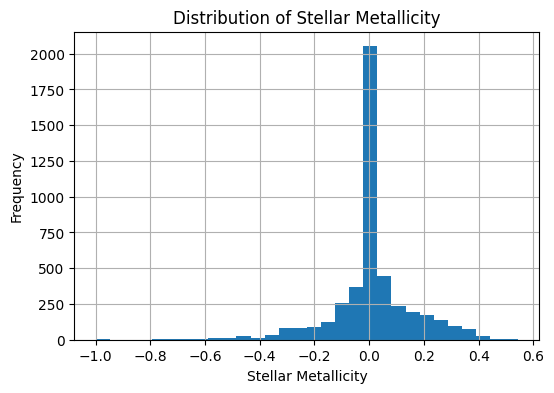

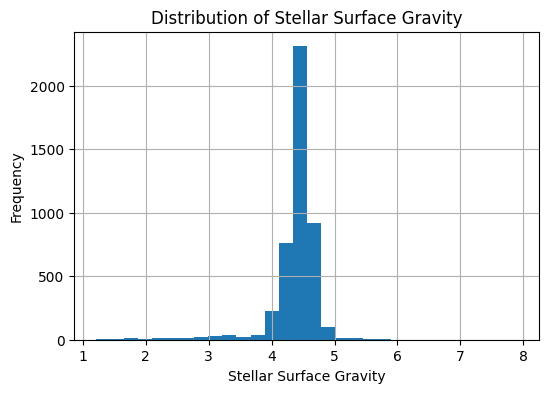

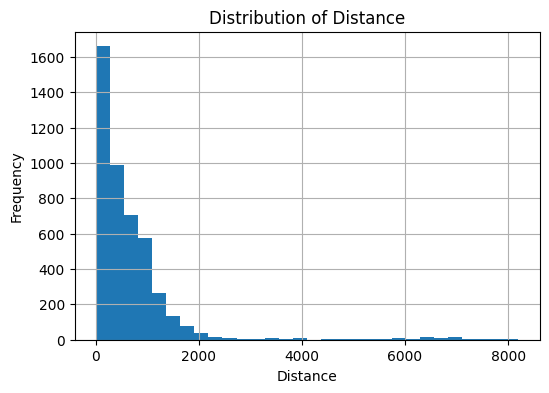

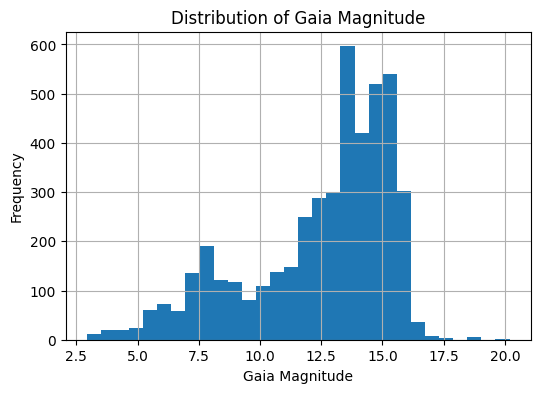

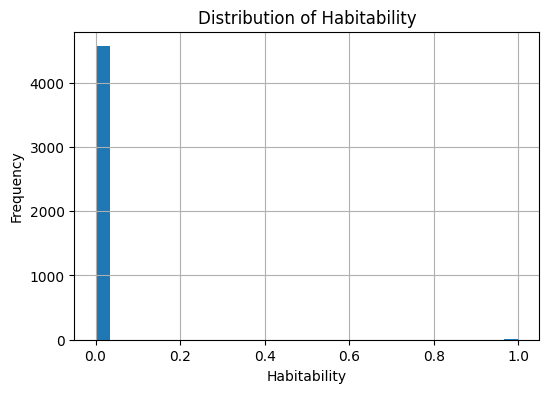

In [23]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Bivariate plots:

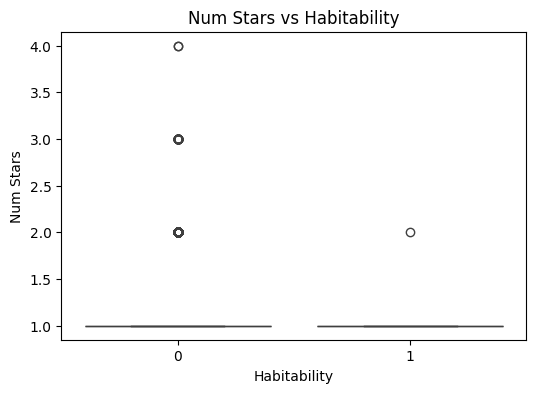

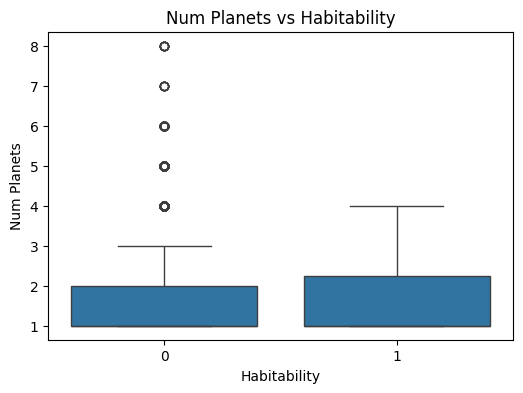

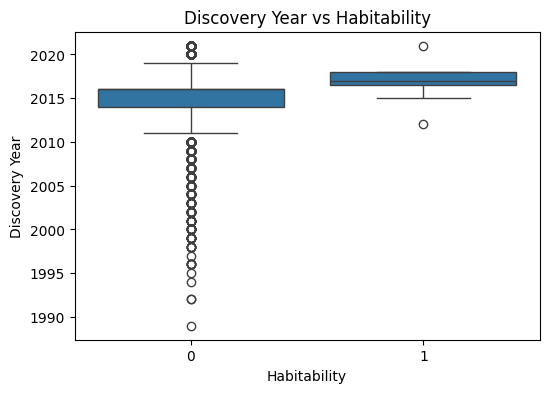

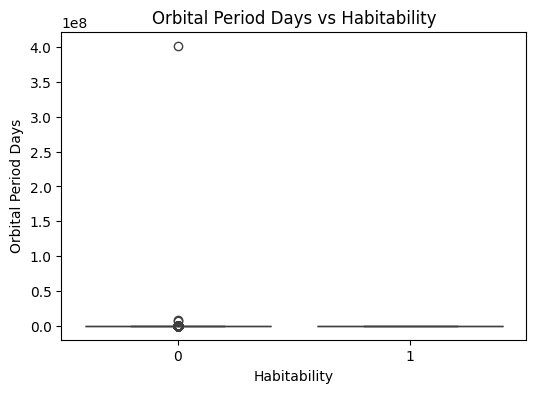

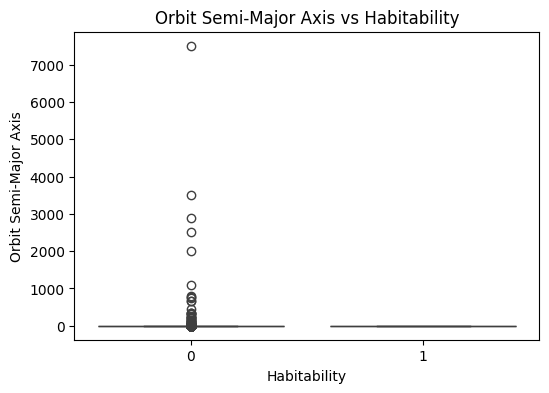

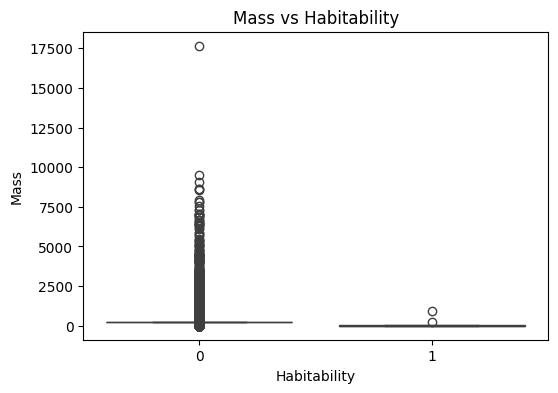

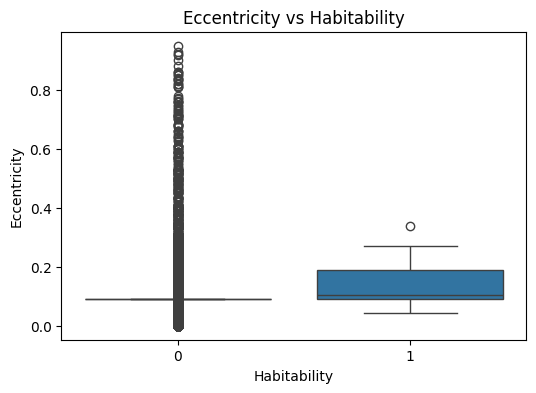

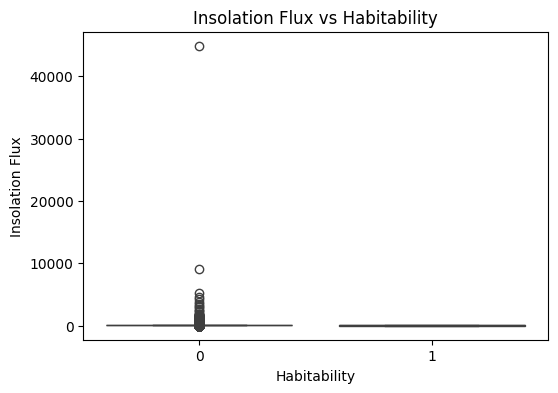

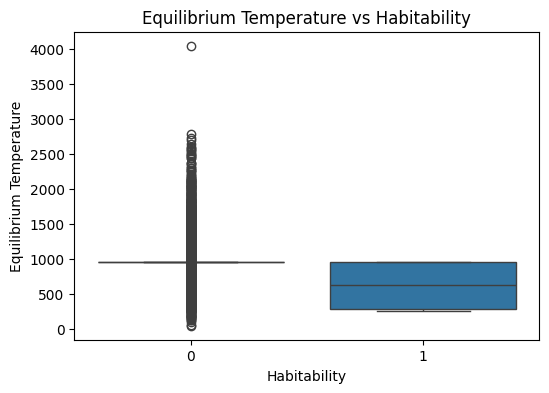

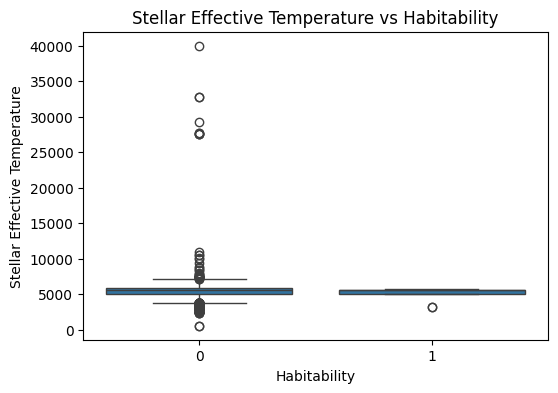

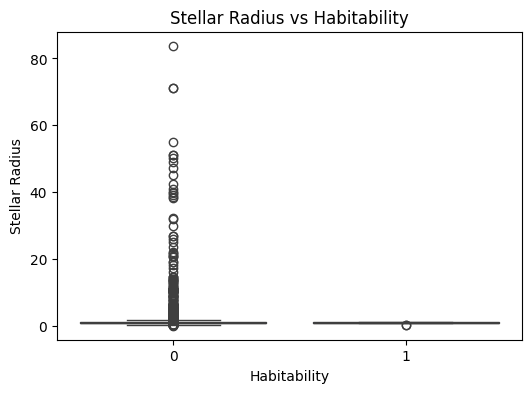

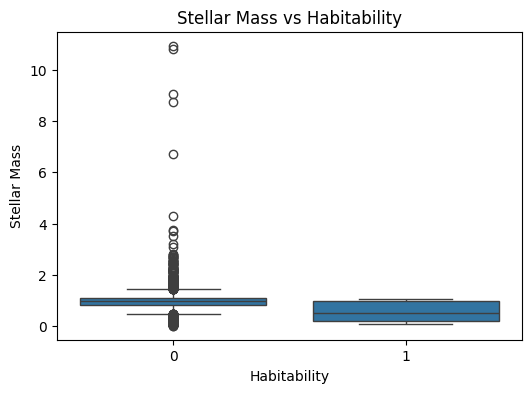

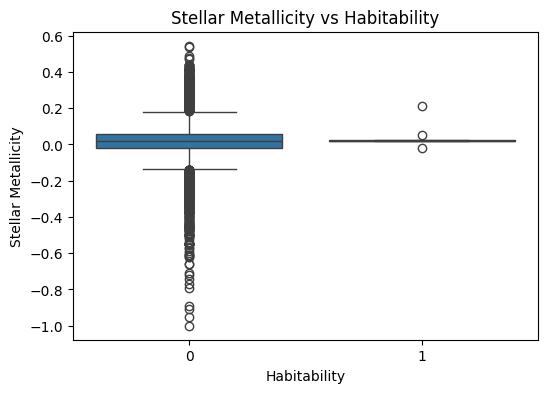

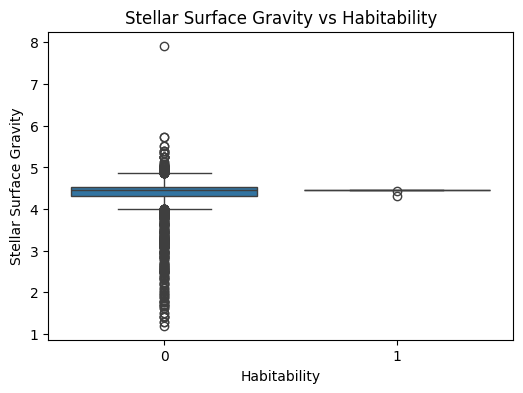

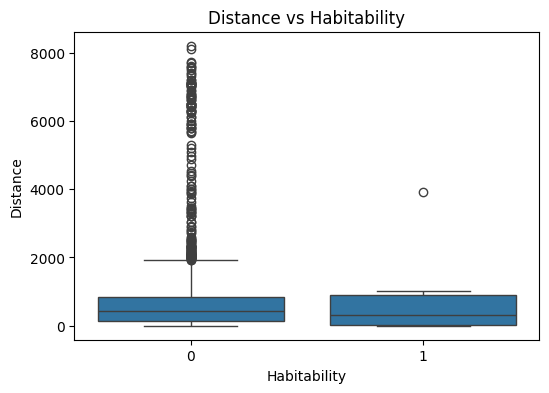

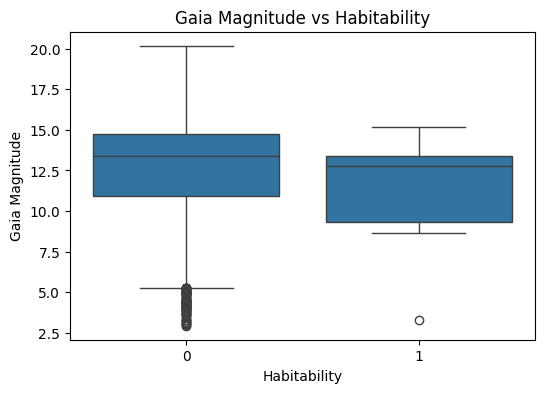

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = [col for col in num_cols if col != "Habitability"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Habitability", y=col, data=df)
    plt.title(f"{col} vs Habitability")
    plt.show()


# **Feature Engineering**

Feature Engineering
 (A) Habitability Score Index (HSI)- HSI tells us how Earth-like a planet is.
 1 / (1 + |actual_value − Earth_value|)


In [24]:
df["Habitability_Score"] = (
    0.3 * (1 / (1 + abs(df["Orbit Semi-Major Axis"] - 1))) +
    0.3 * (1 / (1 + abs(df["Equilibrium Temperature"] - 288)))) + \
    0.2 * (1 / (1 + abs(df["Mass"] - 1))) + \
    0.2 * (1 / (1 + abs(df["Stellar Effective Temperature"] - 5778)))
    # More important → bigger number
    # Less important → smaller number
    # 0.3 + 0.3 + 0.2 + 0.2 = 1


(B) Stellar Compatibility Index (SCI)- It creates a Stellar Compatibility score that tells how similar a star is to our Sun.
1 / (1 + |star_value − Sun_value|)
Closer to Sun → higher score .
Far from Sun → lower score

In [25]:
df["Stellar_Compatibility"] = (
    0.4 * (1 / (1 + abs(df["Stellar Effective Temperature"] - 5778))) +
    0.3 * (1 / (1 + abs(df["Stellar Metallicity"] - 0.0))) +
    0.3 * (1 / (1 + abs(df["Stellar Radius"] - 1))))


# **Feature Selection Using Correlation**

In [26]:
correlation = df.corr(numeric_only=True)

selected_features = correlation["Habitability"][
    abs(correlation["Habitability"]) > 0.05
].index.tolist()

selected_features.remove("Habitability")

X = df[selected_features]
y = df["Habitability"]


In [27]:
selected_features = correlation["Habitability"][abs(correlation["Habitability"]) > 0.05].index.tolist()
selected_features.remove("Habitability")
X = df[selected_features]


Encode Categorical Features
One-hot encoding:

In [28]:
X = pd.get_dummies(X, drop_first=True)


or

In [29]:
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

Split Dataset into Training and Testing Sets (80:20)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


# **Feature Scaling**

Normalize Numerical Features

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


SMOTE only

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Habitability
0    3654
1       6
Name: count, dtype: int64

After SMOTE:
Habitability
0    3654
1    3654
Name: count, dtype: int64


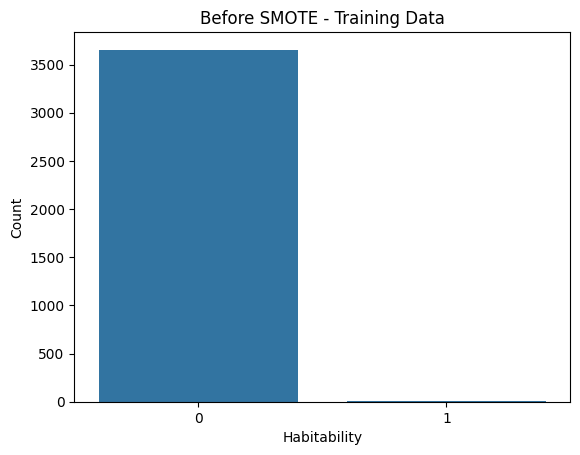

In [33]:
sns.countplot(x=y_train)
plt.title("Before SMOTE - Training Data")
plt.xlabel("Habitability")
plt.ylabel("Count")
plt.show()


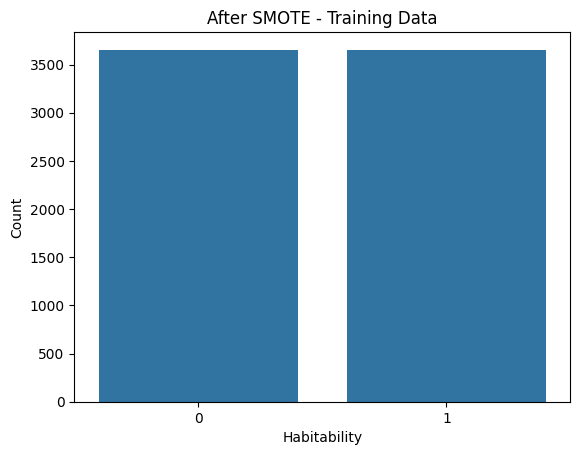

In [34]:
sns.countplot(x=y_train_smote)
plt.title("After SMOTE - Training Data")
plt.xlabel("Habitability")
plt.ylabel("Count")
plt.show()

In [35]:
n_original = X_train_scaled.shape[0]

data_type = ['original'] * n_original + ['smote'] * (len(X_train_smote) - n_original)

df_smote_info = pd.DataFrame({
    'Habitability': y_train_smote,
    'data_type': data_type
})

print(df_smote_info.groupby(['data_type','Habitability']).size())


data_type  Habitability
original   0               3654
           1                  6
smote      1               3648
dtype: int64


Random Undersampling- reduce the majority class(but we lose imp data)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(
    X_train_scaled,
    y_train
)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [37]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

optional

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_res, y_res = rus.fit_resample(X, y)
print(y_res.value_counts())


Habitability
0    8
1    8
Name: count, dtype: int64


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy : 0.9540983606557377
Precision: 0.045454545454545456
Recall   : 1.0
F1-score : 0.08695652173913043

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       913
           1       0.05      1.00      0.09         2

    accuracy                           0.95       915
   macro avg       0.52      0.98      0.53       915
weighted avg       1.00      0.95      0.97       915



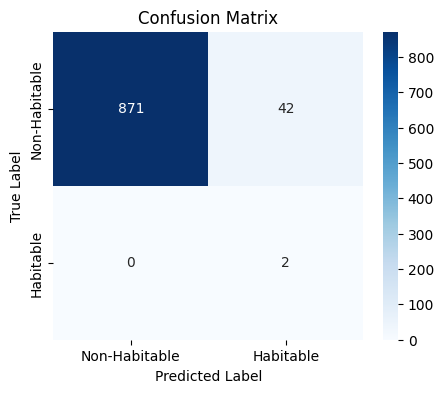

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Habitable", "Habitable"],
    yticklabels=["Non-Habitable", "Habitable"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


svm

In [40]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])


In [41]:
svm_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [67]:
y_pred_svm = svm_pipeline.predict(X_test)


In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print("SVM Accuracy :", accuracy)
print("SVM Precision:", precision)
print("SVM Recall   :", recall)
print("SVM F1-score :", f1)

print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy : 0.966120218579235
SVM Precision: 0.03225806451612903
SVM Recall   : 0.5
SVM F1-score : 0.06060606060606061

SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       913
           1       0.03      0.50      0.06         2

    accuracy                           0.97       915
   macro avg       0.52      0.73      0.52       915
weighted avg       1.00      0.97      0.98       915



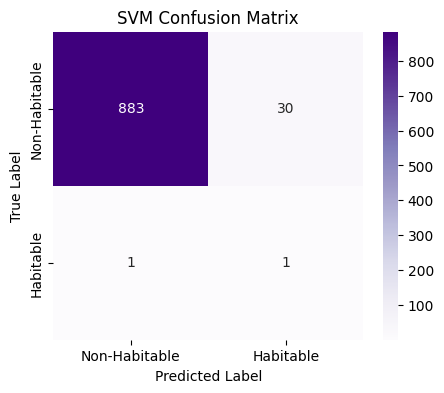

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Non-Habitable", "Habitable"],
    yticklabels=["Non-Habitable", "Habitable"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.show()


PCA

In [58]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop("Habitability", axis=1)
y = df["Habitability"]

X_num = X.select_dtypes(include=["int64", "float64"])
X_scaled = StandardScaler().fit_transform(X_num)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [46]:
svm_2d = SVC(kernel="rbf", class_weight="balanced")
svm_2d.fit(X_pca, y)

SVC(class_weight='balanced')

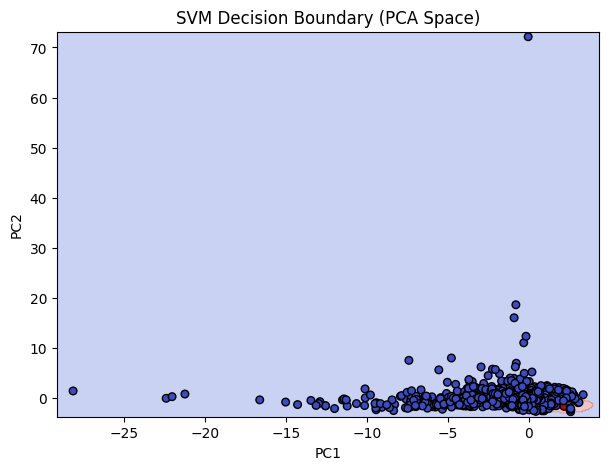

In [59]:
import numpy as np

x_min, x_max = X_pca[:, 0].min()-1, X_pca[:, 0].max()+1
y_min, y_max = X_pca[:, 1].min()-1, X_pca[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=y, cmap="coolwarm", edgecolor="k", s=30
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("SVM Decision Boundary (PCA Space)")
plt.show()


# knn

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ))
])


In [68]:
knn_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(weights='distance'))])

In [69]:
y_pred_knn = knn_pipeline.predict(X_test)


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print("KNN Accuracy :", accuracy)
print("KNN Precision:", precision)
print("KNN Recall   :", recall)
print("KNN F1-score :", f1)

print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))


KNN Accuracy : 0.9967213114754099
KNN Precision: 0.0
KNN Recall   : 0.0
KNN F1-score : 0.0

KNN Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       913
           1       0.00      0.00      0.00         2

    accuracy                           1.00       915
   macro avg       0.50      0.50      0.50       915
weighted avg       1.00      1.00      1.00       915



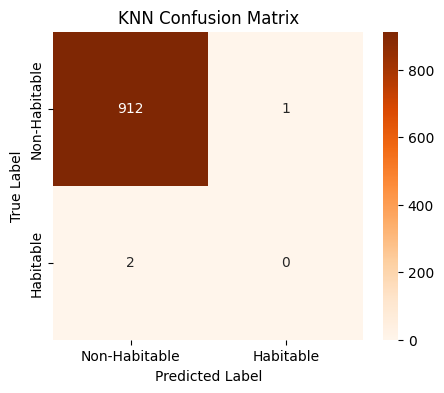

In [73]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Non-Habitable", "Habitable"],
    yticklabels=["Non-Habitable", "Habitable"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN Confusion Matrix")
plt.show()


In [75]:
sample = X_test.iloc[[201]]
sample_prediction = pipeline.predict(sample)

if sample_prediction[0] == 1:
    print(" The planet is predicted as HABITABLE")
else:
    print(" The planet is predicted as NON-HABITABLE")


 The planet is predicted as NON-HABITABLE
